# Output file post-processing #

## Loading time series

The `gtsdf` module provides several functions for post-processing HAWC2 output files in .hdf5 format (resulting from HAWC2 output format = 'gtsdf' or 'gtsdf64'). The basic one is `load`, used for loading the raw time series of an individual .hdf5 file:

In [2]:
from wetb.gtsdf.gtsdf import load

time, data, info = load('../../tutorials/data/res/DLC12_wsp11_wdir000_s1401.hdf5')
print(time) # 100s of initialization, 600s afterwards, timestep = 0.01s
print(data.shape) # 60000 timesteps x 758 output sensors (time is excluded as it is returned in time output separately)
print(info['attribute_descriptions']) # Dict with several keys: filename, sensor names, sensor units, sensor descriptions...


[100.01 100.02 100.03 ... 699.98 699.99 700.  ]
(60000, 758)
['shaft_rot angle', 'shaft_rot angle speed', 'pitch1 angle', 'pitch1 angle speed', 'pitch2 angle', 'pitch2 angle speed', 'pitch3 angle', 'pitch3 angle speed', ' Rotor speed', 'Aero rotor torque', 'Aero rotor power', 'Aero rotor thrust', 'Free wind speed Vx, gl. coo, of gl. pos    0.00,   0.00,-150.00', 'Free wind speed Vy, gl. coo, of gl. pos    0.00,   0.00,-150.00', 'Free wind speed Vz, gl. coo, of gl. pos    0.00,   0.00,-150.00', 'Force  Fx Mbdy:tower nodenr:   1 coo: local  tower base', 'Force  Fy Mbdy:tower nodenr:   1 coo: local  tower base', 'Force  Fz Mbdy:tower nodenr:   1 coo: local  tower base', 'MomentMx Mbdy:tower nodenr:   1 coo: local  tower base', 'MomentMy Mbdy:tower nodenr:   1 coo: local  tower base', 'MomentMz Mbdy:tower nodenr:   1 coo: local  tower base', 'Force  Fx Mbdy:tower nodenr:   2 coo: local  tower 2', 'Force  Fy Mbdy:tower nodenr:   2 coo: local  tower 2', 'Force  Fz Mbdy:tower nodenr:   2 coo:

## Post-processing an individual file

Looking at raw time series is a good sanity check, but the user might be more interested in post-processing time series to obtain some meaningful metrics from them. A post-processing function is any function that takes in the time series of the output channels of an individual HAWC2 output file and returns some output as a `xarray.DataArray`. Many such functions are available in `wetb.utils.postprocs`. For example, `statistics` returns the min, mean, max and std w.r.t. time of each output channel:

In [4]:
from wetb.utils.postprocs import statistics

stats = statistics(time, data, info)
print(stats)

<xarray.DataArray (sensor_name: 758, statistic: 4)> Size: 12kB
array([[1.6995316e-03, 1.7993604e+02, 3.5999850e+02, 1.0375574e+02],
       [5.7843533e+00, 7.4268270e+00, 7.8905778e+00, 4.3500271e-01],
       [0.0000000e+00, 1.5120916e+00, 6.4858394e+00, 2.0208483e+00],
       ...,
       [0.0000000e+00, 2.6390839e-02, 1.1319865e-01, 3.5271499e-02],
       [0.0000000e+00, 2.6390847e-02, 1.1319885e-01, 3.5271522e-02],
       [1.4239211e+01, 2.3017502e+01, 3.3982315e+01, 6.3098574e+00]],
      dtype=float32)
Coordinates:
  * statistic           (statistic) <U4 64B 'min' 'mean' 'max' 'std'
  * sensor_name         (sensor_name) <U24 73kB 'bea1 angle' ... 'DLL inp   5...
    sensor_unit         (sensor_name) <U5 15kB 'deg' 'rpm' 'deg' ... '-' '-' '-'
    sensor_description  (sensor_name) <U77 233kB 'shaft_rot angle' ... 'tower...


## Post-processing multiples files

It is very likely that the user will be interested in post-processing more than one individual .hdf5 file (i.e. for all cases from a parametric study or for a DLB) without loading every single file raw time series. Moreover, the user might want to calculate more than one post-processing function (i.e. `statistics` and `equivalent loads`). `collect_postproc` runs all post-processing functions on all .hdf5 files, re-writes them to add the post-processed results (very useful to avoid re-computing) and also returns a list with a collected `xarray.DataArray` for each post-processing function (collected means that each `xarray.DataArray` has an extra dimension "filename", as it contains the values for all individual .hdf5 files). The post-processings functions are specified through the `config` argument, a dictionary that maps functions to their arguments:

In [ ]:
from wetb.utils.postprocs import equivalent_loads
from wetb.gtsdf.gtsdf import collect_postproc

folder = '../../tutorials/data/res' # Folder containing all .hdf5 files to post-process
config = {statistics: {}, # Dict containing function - args pairs
          equivalent_loads: {}}

postprocs = collect_postproc(folder=folder, config=config)
print('Collected statistics:')
print(postprocs[0]) # statistics
print('Collected equivalent_loads:')
print(postprocs[1]) # equivalent_loads

100%|██████████| 2/2 [00:00<00:00,  5.19it/s]

Collected statistics:
<xarray.DataArray 'statistics' (filename: 2, sensor_name: 758, statistic: 4)> Size: 49kB
array([[[1.69953157e-03, 1.79936035e+02, 3.59998505e+02, 1.03755737e+02],
        [5.78435326e+00, 7.42682695e+00, 7.89057779e+00, 4.35002714e-01],
        [0.00000000e+00, 1.51209164e+00, 6.48583937e+00, 2.02084827e+00],
        ...,
        [0.00000000e+00, 2.63908394e-02, 1.13198653e-01, 3.52714993e-02],
        [0.00000000e+00, 2.63908468e-02, 1.13198847e-01, 3.52715217e-02],
        [1.42392111e+01, 2.30175018e+01, 3.39823151e+01, 6.30985737e+00]],

       [[2.05714907e-02, 1.79926804e+02, 3.59982330e+02, 1.03905121e+02],
        [4.97584009e+00, 7.30491161e+00, 8.06042194e+00, 6.55277312e-01],
        [0.00000000e+00, 2.18736839e+00, 9.04205704e+00, 2.79112983e+00],
        ...,
        [0.00000000e+00, 3.81766222e-02, 1.57812417e-01, 4.87162583e-02],
        [0.00000000e+00, 3.81766073e-02, 1.57812953e-01, 4.87159230e-02],
        [1.41734505e+01, 2.30461273e+01, 3.4009

## Custom post-processing functions

As much as there are plenty of useful post-processing functions already available in `wetb.utils.postprocs`, `wetb` also allows the user to define custom post-processing functions. Such post-processing functions will need to access file-specific variables, so there are a few privileged keywords for their input arguments that wetb will assign to them:
- `time`: it will correspond to the time array, just like returned by `load`.
- `data`: it will correspond to the data array, just like returned by `load`.
- `info`: it will correspond to the info dict, just like returned by `load`.
- `file`: it will correspond to the .hdf5 filename. It is useful when an argument to the function depends on a variable that changes across different .hdf5 files.

Any other argument with a different name will be the same for all .hdf5 files and will have to be specified in `config`.

The example below shows a custom function for computing the actuator duty cycle of the pitch actuators of a turbine. The actuator duty cycle is defined by the total angle an actuator rotates, so the function must integrate the absolute value of the pitch bearing speed for each blade. For doing so, it will need access to `time` (integrates w.r.t. it), `data` (array containing the time series of the pitch bearing speed for each blade) and `info` (to know the units). An additional argument that is not file-specific is "sensor_indices", which specifies the indices of the blade pitch speed sensors:

In [ ]:
import numpy as np
import xarray as xr

def actuator_duty_cycle(time, data, info, sensor_indices) -> xr.DataArray:
    """
    Calculate the duty cycle for different actuators.

    Parameters
    ----------
    time : array (Ntimesteps)
        Array containing the simulation time from start to end of writting output
    data : array (Ntimesteps x Nsensors)
        Array containing the time series of all sensors
    info : dict
        Dictionary that must contain the following entries:
            attribute_names: list of sensor names
            attribute_units: list of sensor units
            attribute_descriptions: list of sensor descriptions
    sensor_indices : list
        List containing the indices for the bearing speed sensors.

    Returns
    -------
    xarray.DataArray 
        DataArray containing the ACD for each actuator.

    """
    ADC = [] # Store the ADC values
    names = [] # Store the sensor names
    units = [] # Store the sensor units
    for s in sensor_indices: # Loop over the specified sensors
        # Integrate the absolute value of the sensor w.r.t. to time
        if info['attribute_units'][s] == 'rpm':
            ADC.append(np.trapezoid(abs(data[:, s]) * 2 * np.pi / 60, time))
            units.append('rad')
        else:
            ADC.append(np.trapezoid(abs(data[:, s]), time))
            units.append(info['attribute_units'][s][:3])
        names.append(info['attribute_descriptions'][s][:info['attribute_descriptions'][s].find(' ')])            
    data = np.array(ADC)
    dims = ['sensor_name']
    coords = {'sensor_name': names,
              'sensor_unit': ('sensor_name', units)}
    return xr.DataArray(data=data, dims=dims, coords=coords)

config = {actuator_duty_cycle: {'sensor_indices': [3, 5, 7]}}

actuator_duty_cycle = collect_postproc(folder=folder, config=config)[0]
print(actuator_duty_cycle)

100%|██████████| 2/2 [00:00<00:00, 106.62it/s]

<xarray.DataArray 'actuator_duty_cycle' (filename: 2, sensor_name: 3)> Size: 48B
array([[34.23766406, 34.23531677, 34.23597882],
       [50.02592765, 50.02140628, 50.02289461]])
Coordinates:
  * sensor_name  (sensor_name) <U6 72B 'pitch1' 'pitch2' 'pitch3'
    sensor_unit  (sensor_name) <U3 36B 'deg' 'deg' 'deg'
  * filename     (filename) <U55 440B '..\\..\\tutorials\\data\\res\\DLC12_ws...


Let's show now an example where an input argument changes across different .hdf5 files. In this example, we have run a parametric study that varies the aspect ratio AR = H / R and tip speed ratio TSR = omega * R / V of a vertical axis turbine rotating at constant speed in uniform inflow. We want to compute how the power and thrust coefficients vary w.r.t. both AR and TSR. Since AR and TSR vary across cases, we will need to extract them with the `file` argument. Additionally, the function will take in air density, angular speed, rotor radius and a regular expression (needed for extracting AR and TSR from the filename):

In [8]:
import os
import re

def integral_coefficients(file, time, data, info, rho, omega, R, regex):
    """
    Calculate the integral Ct and Cp of a vertical axis turbine.

    Parameters
    ----------
    file : str
        Path to filename of an individual .hdf5 file
    time : array (Ntimesteps)
        Array containing the simulation time from start to end of writting output
    data : array (Ntimesteps x Nsensors)
        Array containing the time series of all sensors
    info : dict
        Dictionary that must contain the following entries:
            attribute_names: list of sensor names
            attribute_units: list of sensor units
            attribute_descriptions: list of sensor descriptions
    rho : float
        Air density in kg / m ** 3
    omega: float
        Angular speed in rad / s
    R: float
        Rotor radius in m
    regex: str
        Regular expression for extracting AR and TSR from filename

    Returns
    -------
    xarray.DataArray 
        DataArray containing the Ct and Cp.

    """
    # Read the time series of thrust, power and azimuth
    T = data[:, info['attribute_names'].index('Ae rot. thrust')]
    P = data[:, info['attribute_names'].index('Ae rot. power')]
    azi = data[:, info['attribute_names'].index('bea3 angle')]
    
    # Find the indices corresponding to the time instants at
    # the beginning and end of the last full revolution
    i = -1
    find_end = True
    while True:
        if azi[i-1] > azi[i]:
            if find_end:
                end = i
                find_end = False
            else:
                start = i 
                break
        i = i - 1
    
    # Parse the filename to extract AR and TSR
    match = re.match(regex, os.path.basename(file))
    AR = float(match.group(2))
    TSR = float(match.group(1))
    
    # Finally compute the coefficients
    V = omega * R / TSR
    H = AR * R
    A = 2 * R * H
    Ct = 1000 * np.mean(T[start:end]) / (0.5 * rho * V ** 2 * A)
    Cp = 1000 * np.mean(P[start:end]) / (0.5 * rho * V ** 3 * A)
    data = np.array([Ct, Cp])
    dims = ['coefficient']
    coords = {'coefficient': ['Ct', 'Cp']}
    return xr.DataArray(data=data, dims=dims, coords=coords)

config = {integral_coefficients: {'rho': 1.225, # Only specify the arguments that are not file-specific!
                                  'omega': np.pi / 5,
                                  'R': 23,
                                  'regex': 'TSR(\d+(?:\.\d+)?)_AR(\d+(?:\.\d+)?)'}}

integral_coefficients = collect_postproc(folder='../../tutorials/data/res/vawt', config=config)[0]
print(integral_coefficients)

100%|██████████| 45/45 [00:01<00:00, 38.61it/s]

<xarray.DataArray 'integral_coefficients' (filename: 45, coefficient: 2)> Size: 720B
array([[0.55327153, 0.3818931 ],
       [0.57190388, 0.4074645 ],
       [0.58188683, 0.42152116],
       [0.58806938, 0.43035522],
       [0.59225792, 0.43639445],
       [0.59527642, 0.44077238],
       [0.59755319, 0.44408697],
       [0.59933126, 0.44668141],
       [0.60075808, 0.44876662],
       [0.61425835, 0.40783527],
       [0.63426036, 0.43434748],
       [0.64496422, 0.44889161],
       [0.65158838, 0.458022  ],
       [0.6560744 , 0.46426004],
       [0.65930647, 0.46878037],
       [0.661744  , 0.47220185],
       [0.66364723, 0.47488001],
       [0.6651749 , 0.47703224],
       [0.66713738, 0.42612791],
       [0.68800622, 0.4530043 ],
...
       [0.71858764, 0.49395448],
       [0.72017545, 0.49612579],
       [0.71248138, 0.43819994],
       [0.73384333, 0.4650858 ],
       [0.74523437, 0.47976953],
       [0.752271  , 0.48896655],
       [0.75703096, 0.49524218],
       [0.76045889, 

Note that the key to extracting parameters that vary across different files is `filename`, but using a regular expression to parse it is not mandatory. If a parameter of interest is not present in `filename`, the user can implement a mapping between each filename and its corresponding parameter inside the custom function. This is the recommended approach when dealing with studies with so many parameters that keeping them all in the name is cumbersome or even impossible.

The `xarray.DataArray` is very convenient for further manipulation in Python. There is a very useful function in `wetb.dlb.dlb_postprocs` called `add_coords_from_filename` that will add coordinates to the `xarray.DataArray` by extracting the specified parameters from the filenames through a regular expression:

In [9]:
from wetb.dlb.dlb_postprocs import add_coords_from_filename

integral_coefficients = add_coords_from_filename(dataarray=integral_coefficients,
                                                 params=['ar', 'tsr'],
                                                 regex='TSR(\d+(?:\.\d+)?)_AR(\d+(?:\.\d+)?)',
                                                 formats=[float, float])
print(integral_coefficients.coords)

Coordinates:
  * coefficient  (coefficient) <U2 16B 'Ct' 'Cp'
  * filename     (filename) <U47 8kB '..\\..\\tutorials\\data\\res\\vawt\\TSR...
    ar           (filename) float64 360B 3.0 3.0 3.0 3.0 3.0 ... 5.0 5.0 5.0 5.0
    tsr          (filename) float64 360B 1.0 1.5 2.0 2.5 3.0 ... 3.5 4.0 4.5 5.0


Now we can, for instance, plot the Cp and Ct surface levels w.r.t. TSR and AR:

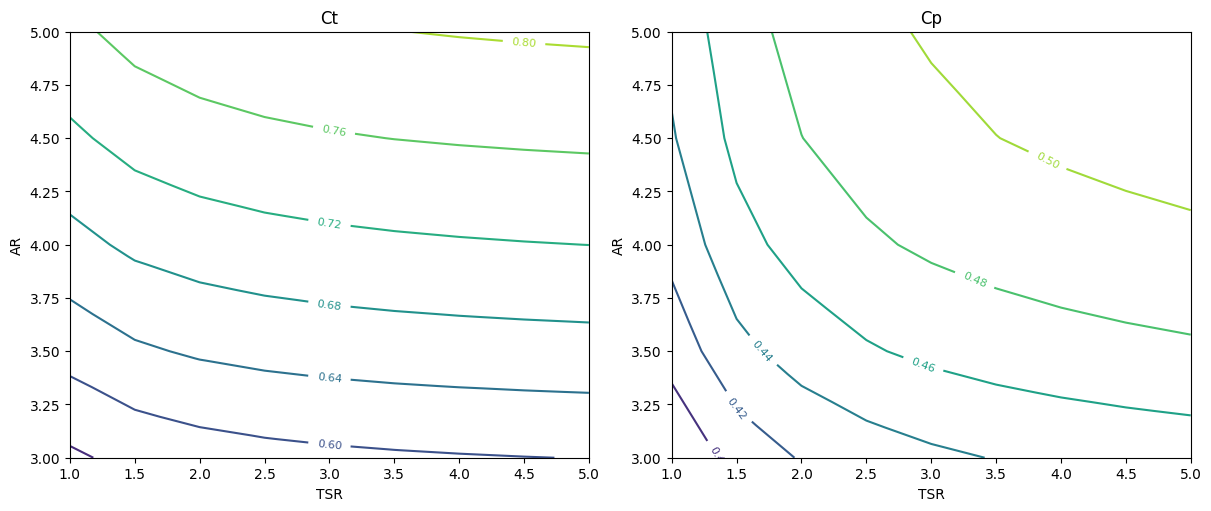

In [10]:
import matplotlib.pyplot as plt

ct = integral_coefficients.sel(coefficient='Ct').data
cp = integral_coefficients.sel(coefficient='Cp').data
tsr = integral_coefficients.tsr.data
ar = integral_coefficients.ar.data

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

cs1 = axes[0].tricontour(tsr, ar, ct)
axes[0].set_xlabel('TSR')
axes[0].set_ylabel('AR')
axes[0].set_title('Ct')
axes[0].clabel(cs1, inline=True, fontsize=8)

cs2 = axes[1].tricontour(tsr, ar, cp)
axes[1].set_xlabel('TSR')
axes[1].set_ylabel('AR')
axes[1].set_title('Cp')
axes[1].clabel(cs2, inline=True, fontsize=8)

plt.show()